In [58]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit

In [59]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

In [60]:
print(len(dataF[0]))

4097


C:\Users\rjnar\AppData\Local\Temp\ipykernel_16300\3818996941.py:10: RuntimeWarning: invalid value encountered in power
  return c / ((x + b) ** a)


KeyboardInterrupt: 

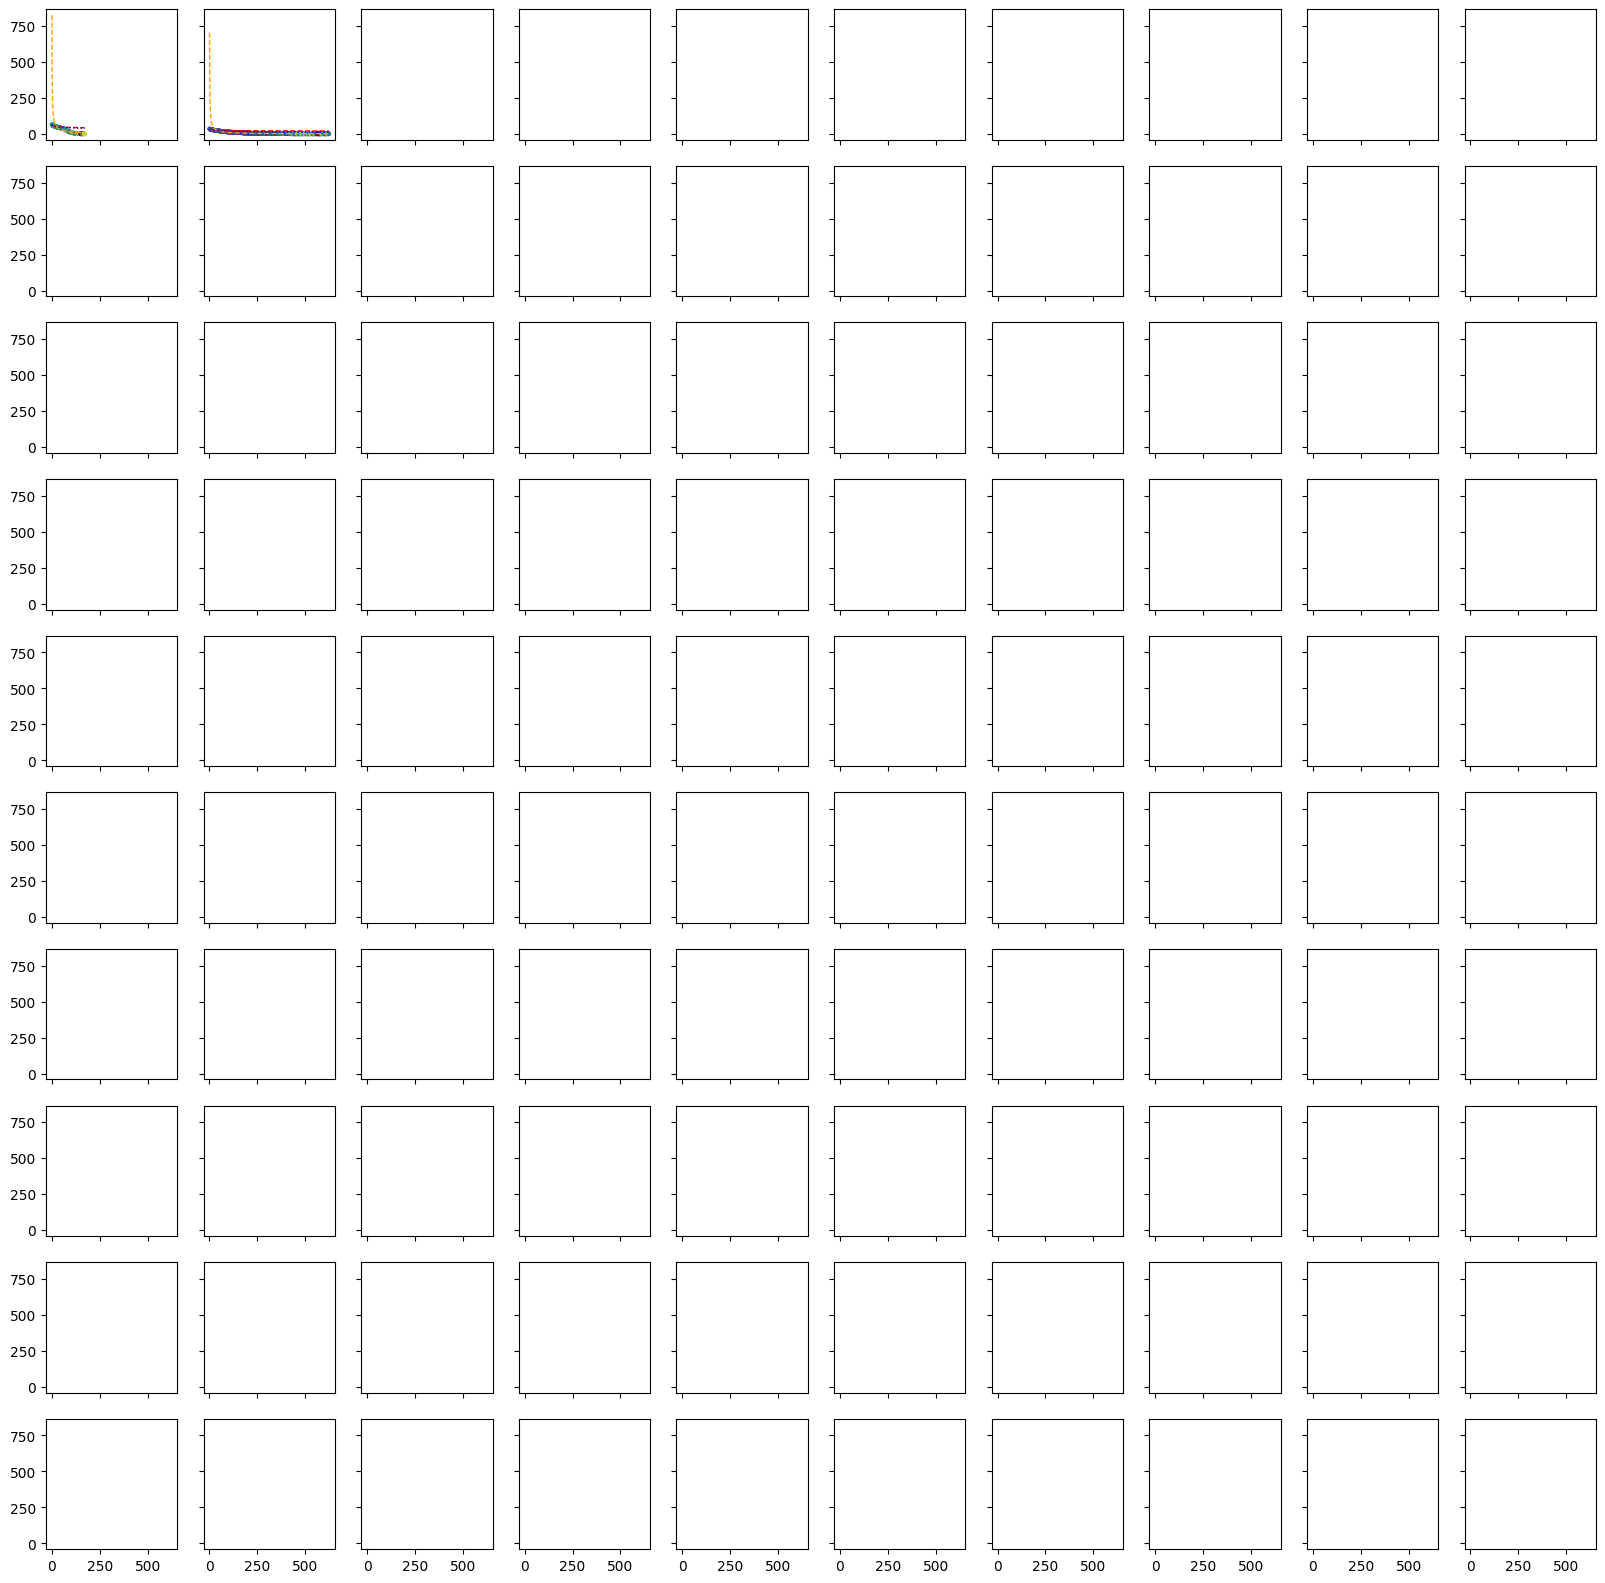

In [61]:
n_rows, n_cols = 10, 10  # fixed 10x10 grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 20), sharex=True, sharey=True)
axes = axes.flatten()

# --- Model functions ---
def power_law(x, a, b):
    return a * x**(-b)

def zipf_mandelbrot(x, c, a, b):
    return c / ((x + b) ** a)

for i, row in enumerate(dataF):
    ax = axes[i]

    # Count frequencies
    counts = Counter(row)
    values, freqs = zip(*sorted(counts.items(), key=lambda x: x[1], reverse=True))
    values = np.array(values)
    freqs = np.array(freqs)
    ranks = np.arange(1, len(freqs) + 1)

    # Scatter plot (color by value)
    sc = ax.scatter(ranks, freqs, c=values, cmap="viridis", s=5)
    #ax.set_xscale('log')
    #ax.set_yscale('log')

    # --- Define cutoff based on top 20% of datapoints ---
    total = freqs.sum()
    cumulative = np.cumsum(freqs)
    cutoff_rank = np.searchsorted(cumulative, 0.2 * total) + 1  # first rank where >= 20%
    cutoff_rank = max(2, cutoff_rank)  # ensure at least 2 points

    # Split into top 20% vs bottom 80%
    x_fit_top, y_fit_top = ranks[:cutoff_rank], freqs[:cutoff_rank]
    x_fit_bottom, y_fit_bottom = ranks[cutoff_rank:], freqs[cutoff_rank:]

    try:
        # --- Power-law fit (top 20%) ---
        popt, _ = curve_fit(power_law, x_fit_top, y_fit_top, p0=[y_fit_top[0], 1.0], maxfev=5000)
        a, b = popt
        x_line = np.logspace(np.log10(1), np.log10(len(ranks)), 500)
        ax.plot(x_line, power_law(x_line, a, b), color="red", linestyle="--", linewidth=1, label="Power law (top 20%)")
    except RuntimeError:
        pass

    try:
        # --- Power-law fit (bottom 80%) ---
        if len(x_fit_bottom) >= 2:
            popt, _ = curve_fit(power_law, x_fit_bottom, y_fit_bottom, p0=[y_fit_bottom[0], 1.0], maxfev=5000)
            a, b = popt
            x_line = np.logspace(np.log10(1), np.log10(len(ranks)), 500)
            ax.plot(x_line, power_law(x_line, a, b), color="orange", linestyle="--", linewidth=1, label="Power law (bottom 80%)")
    except RuntimeError:
        pass

    try:
        # --- Zipf-Mandelbrot fit (top 20%) ---
        popt, _ = curve_fit(zipf_mandelbrot, x_fit_top, y_fit_top, p0=[y_fit_top[0], 1.0, 1.0], maxfev=5000)
        c, a, b = popt
        x_line = np.logspace(np.log10(1), np.log10(len(ranks)), 500)
        ax.plot(x_line, zipf_mandelbrot(x_line, c, a, b), color="blue", linestyle=":", linewidth=1, label="Zipf-Mandelbrot (top 20%)")
    except RuntimeError:
        pass

    try:
        # --- Zipf-Mandelbrot fit (whole dataset) ---
        if len(ranks) >= 2:
            popt, _ = curve_fit(zipf_mandelbrot, ranks, freqs, p0=[freqs[0], 1.0, 1.0], maxfev=5000)
            c, a, b = popt
            x_line = np.logspace(np.log10(1), np.log10(len(ranks)), 500)
            ax.plot(x_line, zipf_mandelbrot(x_line, c, a, b), color="green", linestyle="-.", linewidth=1, label="Zipf-Mandelbrot (whole)")
    except RuntimeError:
        pass

# Hide any unused subplots (if < 100 series)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Global labels
fig.text(0.5, 0.04, 'Rank (log scale)', ha='center')
fig.text(0.04, 0.5, 'Frequency (log scale)', va='center', rotation='vertical')

# Shared colorbar
fig.colorbar(sc, ax=axes, orientation="vertical", fraction=0.02, pad=0.01, label="Value")

# --- Single shared legend for all plots ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=8, frameon=False)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.90])
plt.savefig('F_normnorm.png', dpi=300)
plt.show()
